# On-Device RAG Performance: A Quantization & Architecture Benchmark

Running a RAG pipeline on-device means every model choice carries a dual cost: answer quality *and* system load. This analysis focuses on small Mistral-family models — Ministral 3 (3B and 8B parameters) and Mistral 7B v0.3 — evaluated across quantization levels from Q1 to Q8, with the goal of mapping accurate quality–cost tradeoffs for context-grounded answer generation. Llama 3.2 3B serves as a widely-used small-model alternative for direct comparison, and Mistral Large via API provides the quality ceiling: what a capable, unconstrained model would score on the same questions.

The experiment holds retrieval constant — all configurations share the same `e5-large` retriever and ChromaDB collection — so that differences in answer correctness, faithfulness, and hallucination can be attributed squarely to the generator. Alongside these RAG-specific quality metrics, every inference is instrumented with latency, throughput, and hardware utilisation measurements, enabling direct reasoning about which configurations deliver good answers at acceptable system cost and which do not.

## The Benchmarking Tool

All results in this notebook were collected using **[RAGrig](https://github.com/n-ploch/on-device-rag-performance)**, an open-source orchestration tool that instruments a full RAG pipeline with [OpenTelemetry](https://opentelemetry.io/) (OTEL) spans, making retrieval and generation fully traceable and exportable to any OTEL-compatible backend. The tool follows an Orchestrator + Worker architecture: the Orchestrator drives the evaluation loop and ships OTEL spans to any external tracing tool, i.e., a self-hosted [Langfuse](https://langfuse.com/) instance as used for these experiments, while the Worker runs quantized GGUF models via `llama.cpp` servers on any hardware — Apple Silicon, NVIDIA GPUs, or CPU-only edge devices — making the benchmark reproducible across platforms.

---
## Experimental Setup

### RAG Pipeline

The benchmark uses a standard two-stage RAG pipeline with a fixed retrieval model and variable generation model:

- **Dataset:** eManuals subset from [RAGBench](https://huggingface.co/datasets/rungalileo/ragbench) — 61 questions drawn from consumer electronics manuals, each with ground-truth answers and annotated relevant context chunks
- **Retrieval model:** `intfloat/multilingual-e5-large` (1024-dim embeddings, Q4 quantized), returning top-6 chunks via cosine similarity from a local ChromaDB collection
- **Generator prompt:** The system prompt instructs the model to answer from the provided context chunks; completion capped at 256 tokens
- **Evaluator:** Qwen3 scores each answer on three dimensions as judge

### Generator Models Tested

| Family | Parameters | Quantizations |
|---|---|---|
| Llama 3.2 | 3B | IQ1, Q2, Q3, Q4, Q5, Q8 |
| Ministral 3 | 3B | Q4, Q5, Q8 |
| Ministral 3 | 8B | Q4, Q5 |
| Mistral 7B v0.3 | 7B | IQ3, Q3\_L, Q4, Q8 |
| Mistral Large 3 | 675B | API (quality ceiling) |

The generators where queried with the following parameters:
```
{
            "max_tokens": 256,
            "temperature": 0.7,
            "top_p": 0.95,
            "stream": False,
}
```

### Hardware under test
The results in this notebook where collected on an Apple MacBook Pro with M1 chip (10-Core CPU, 16-Core Neural Engine, 16GB memory) leveraging Apple's Metal Performance Shaders.


### Running the benchmark
One run configuration includes a dataset (with ground truth entries), a retrieval configuration, and a generation configuration. If the ChromaDB collection needed for a specific retrieval config is not existing yet, it is created. The latency for that is not accounted for in the benchmark.

Each configuration collected for this analysis runs 61 claims. Multiple repeated sessions were performed per configuration for stability analysis; this notebook focuses on cross-model comparisons averaging over all runs per configuration. In the appendix, you will find evaluation plots per claim ID. 


## Evaluation

### LLM Evaluation Metrics

Each claim is scored by three Qwen3-235B-based judges:

| Metric | Range | Interpretation |
|---|---|---|
| **Correctness** | 0–1 | Does the answer correctly address the question? Higher is better. |
| **Hallucination** | 0–1 | Does the answer contain completely fabricated statements? Lower is better. |
| **Faithfulness** | 0–1 | Are all answer claims traceable to the retrieved context? Higher is better. |

A few notes on how each judge works:

**Correctness**: Checks whether the answer covers all key facts from the ground truth. A score of 1 means every ground-truth fact is present; lower scores reflect missing or incorrect information.

**Faithfulness** (adapted from [RAGAS](https://docs.ragas.io/en/stable/concepts/metrics/available_metrics/faithfulness/)): Measures how strictly the answer stays within the retrieved context. The judge breaks the answer into individual statements and checks each one for inferability from the context chunks. Score = verifiable statements / total statements.

**Hallucination**: Identifies statements that cannot be traced to either the retrieved context or the ground truth and that the judge determines are fabricated, drawing on its knowledge of the question and domain. This metric is particularly discriminating on the eManuals dataset: because questions are tightly coupled to specific product documentation, any answer that reaches beyond the provided chunks tends to invent domain-specific details. Score is relative to the amount of hallucinated statements as compared in the answer.

### Key latency and hardware metrics:

| Metric | Description |
|---|---|
| **E2E latency p90 (ms)** | Wall-clock time from query to final token, 90th percentile |
| **TTFT p90 (ms)** | Time-to-first-token — reflects prompt encoding overhead, 90th percentile |
| **Tokens/sec** | Generation throughput, median |
| **Completion tokens** | Output length, median |
| **RAM (MB)** | Peak physical memory usage, median |

In [34]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, str(Path.cwd()))

from utils import (
    load_files,
    print_dataset_info,
    exclude_outliers,
    plot_boxplots,
    plot_stats_bar,
    plot_stats_multi_line,
    plot_stats_line,
    plot_grouped_bars,
    plot_heatmap,
    plot_dot_profiles,
    plot_scatter_two_metrics,
    plot_latency_as_hist,
    plot_generation_as_hist,
    plot_hardware_as_hist,
    _present,
    METRIC_LABELS,
    LATENCY_COLS,
    GENERATION_COLS,
    HARDWARE_COLS,
)

plt.rcParams['figure.dpi'] = 110

EXPORT_DIR = Path('../local/metric-export/eval2')
df_raw = load_files(folder=EXPORT_DIR, pattern='*langfuse_export*.parquet')
df = exclude_outliers(df_raw, method='iqr', threshold=3.0)
print_dataset_info(df)

run_order = [
    'e5_large_llama_3_2_3B_q1_61',
    'e5_large_llama_3_2_3B_q2_61',
    'e5_large_llama_3_2_3B_q3_61',
    'e5_large_llama_3_2_3B_q4_61',
    'e5_large_llama_3_2_3B_q5_61',
    'e5_large_llama_3_2_3B_q8_61',
    'e5_large_test_ministral_3_3B_q4_61',
    'e5_large_test_ministral_3_3B_q5_61',
    'e5_large_test_ministral_3_3B_q8_61',
    'e5_large_test_ministral_3_8B_q4_61',
    'e5_large_test_ministral_3_8B_q5_61',
    'e5_large_test_mistral_7B_0_3_iq3_61',
    'e5_large_test_mistral_7B_0_3_q3l_61',
    'e5_large_test_mistral_7B_0_3_q4_61',
    'e5_large_test_mistral_7B_0_3_q8_61',
    'e5_large_mistral_large_latest_61',
]

labels = {
    'e5_large_test_ministral_3_3B_q4_61': 'Ministral3 3B Q4',
    'e5_large_test_ministral_3_3B_q5_61': 'Ministral3 3B Q5',
    'e5_large_test_ministral_3_3B_q8_61': 'Ministral3 3B Q8',
    'e5_large_test_ministral_3_8B_q4_61': 'Ministral3 8B Q4',
    'e5_large_test_ministral_3_8B_q5_61': 'Ministral3 8B Q5',
    'e5_large_test_mistral_7B_0_3_iq3_61': 'Mistral 7Bv0.3 IQ3',
    'e5_large_test_mistral_7B_0_3_q3l_61': 'Mistral 7Bv0.3 Q3L',
    'e5_large_test_mistral_7B_0_3_q4_61': 'Mistral 7Bv0.3 Q4',
    'e5_large_test_mistral_7B_0_3_q8_61': 'Mistral 7Bv0.3 Q8',
    'e5_large_mistral_large_latest_61': 'Mistral Large (Benchmark)',
    'e5_large_llama_3_2_3B_q1_61': 'Llama 3.2 3B IQ1',
    'e5_large_llama_3_2_3B_q2_61': 'Llama 3.2 3B Q2',
    'e5_large_llama_3_2_3B_q3_61': 'Llama 3.2 3B Q3',
    'e5_large_llama_3_2_3B_q4_61': 'Llama 3.2 3B Q4',
    'e5_large_llama_3_2_3B_q5_61': 'Llama 3.2 3B Q5',
    'e5_large_llama_3_2_3B_q8_61': 'Llama 3.2 3B Q8',
}

quality_cols = ['score_Correctness', 'score_Evaluate Hallucination V2', 'score_Faithfulness custom']


Loading: 2026-03-11_11-44_langfuse_export_e5_large_test_ministral_3_3B_q5_61_67d3dd6d.parquet
Loading: 2026-03-11_11-44_langfuse_export_e5_large_test_ministral_3_3B_q8_61_7ee0add1.parquet
Loading: 2026-03-11_11-44_langfuse_export_e5_large_test_ministral_3_8B_q4_61_cdf192c3.parquet
Loading: 2026-03-11_11-44_langfuse_export_e5_large_test_ministral_3_8B_q5_61_5409d5d5.parquet
Loading: 2026-03-11_11-44_langfuse_export_e5_large_test_mistral_7B_0_3_iq3_61_e2c616ff.parquet
Loading: 2026-03-11_11-44_langfuse_export_e5_large_test_mistral_7B_0_3_q3l_61_1615373d.parquet
Loading: 2026-03-11_11-44_langfuse_export_e5_large_test_mistral_7B_0_3_q4_61_e70af912.parquet
Loading: 2026-03-11_11-44_langfuse_export_e5_large_test_mistral_7B_0_3_q8_61_7749bcc4.parquet
Loading: 2026-03-11_11-45_langfuse_export_e5_large_test_ministral_3_3B_q4_61_1550665d.parquet
Loading: 2026-03-11_11-45_langfuse_export_e5_large_test_ministral_3_3B_q4_61_9b1925cc.parquet
Loading: 2026-03-11_11-45_langfuse_export_e5_large_test_mi

In [35]:
# Summary table: key metrics per model configuration
agg_df = df.groupby('run_id').agg(
    Correctness=('score_Correctness', 'mean'),
    Hallucination=('score_Evaluate Hallucination V2', 'mean'),
    Faithfulness=('score_Faithfulness custom', 'mean'),
    Tokens_per_sec=('generation_tokens_per_second', 'median'),
    Completion_tokens=('generation_completion_tokens', 'median'),
    RAM_MB=('hardware_max_ram_usage_mb', 'median'),
).round(2)

p90 = (
    df.groupby('run_id')[['latency_e2e_latency_ms', 'latency_ttft_ms']]
    .quantile(0.9)
    .round(0)
    .astype(int)
)
p90.columns = ['E2E p90 (ms)', 'TTFT p90 (ms)']
agg_df = agg_df.join(p90)
agg_df.columns = [
    'Correctness', 'Hallucination', 'Faithfulness',
    'Tokens/sec', 'Completion tokens', 'RAM (MB)',
    'E2E p90 (ms)', 'TTFT p90 (ms)',
]
agg_df = agg_df.reindex([r for r in run_order if r in agg_df.index])
agg_df.index = agg_df.index.map(lambda x: labels.get(x, x))

(
    agg_df.style
    .background_gradient(subset=['Correctness', 'Faithfulness'], cmap='RdYlGn', axis=0)
    .background_gradient(subset=['Hallucination'], cmap='RdYlGn_r', axis=0)
    .background_gradient(subset=['E2E p90 (ms)', 'TTFT p90 (ms)', 'RAM (MB)'], cmap='RdYlGn_r', axis=0)
    .background_gradient(subset=['Tokens/sec'], cmap='RdYlGn', axis=0)
    .background_gradient(subset=['Completion tokens'], cmap='Blues', axis=0)
    .format({
        'Correctness': '{:.2f}', 'Hallucination': '{:.2f}', 'Faithfulness': '{:.2f}',
        'Tokens/sec': '{:.1f}', 'RAM (MB)': '{:.0f}', 'Completion tokens': '{:.0f}'
    })
)

,Correctness,Hallucination,Faithfulness,Tokens/sec,Completion tokens,RAM (MB),E2E p90 (ms),TTFT p90 (ms)
run_id,,,,,,,,
Llama 3.2 3B IQ1,0.16,0.84,0.23,44.9,256,6539,7089,1221
Llama 3.2 3B Q2,0.67,0.25,0.83,47.9,256,8657,6737,1272
Llama 3.2 3B Q3,0.68,0.23,0.83,46.5,138,8123,6689,1270
Llama 3.2 3B Q4,0.65,0.21,0.82,51.4,150,7595,6401,1261
Llama 3.2 3B Q5,0.67,0.22,0.81,42.5,180,8101,7181,1331
Llama 3.2 3B Q8,0.63,0.26,0.82,41.2,184,8614,7346,1210
Ministral3 3B Q4,0.74,0.21,0.83,48.1,256,7323,6714,1375
Ministral3 3B Q5,0.72,0.22,0.85,38.9,253,7699,8243,1473
Ministral3 3B Q8,0.73,0.21,0.83,37.9,256,8453,8091,1213


---
## Key Findings at a Glance

Three patterns stand out immediately from the summary table and are explored in detail in the sections that follow.

**Scaling from 3B to 7/8B is a latency multiplier, but generates quality improvements.** Moving from Ministral 3B to 8B approximately doubles E2E p90 latency (from ~6,700 ms to ~14,600 ms) and TTFT (~1,400 ms → ~3,100 ms). The quality return in exchange is real: hallucination drops by roughly 6–10 percentage points and faithfulness improves by a similar margin. The nature of these trade-offs and when it is worth paying are examined in the [More Parameters Reduce Hallucination, But Latency Grows](#more-parameters-reduce-hallucination-but-latency-grows) section. Interestingly, RAM usage does not scale the same way. In fact, it stays in a similar range for Mistral 7B models.

**Ministral 3B outperforms Llama 3.2 3B at comparable or lower system cost.** At Q4, Ministral 3B achieves a correctness score of 0.74 versus 0.65 for Llama — a gap of nearly 10 percentage points — with similar or modest advantages in hallucination (0.21 vs 0.21) and faithfulness (0.83 vs 0.82). This comes with a slightly higher TTFT (~1,375 ms vs ~1,261 ms) but lower RAM usage (7,323 MB vs 7,595 MB). Whether this advantage holds up across quantization levels and retrieval conditions is explored in the [Mistral Family Clearly Outperforms Llama 3.2](#mistral-family-clearly-outperforms-llama-32) and [Retrieval Robustness](#when-retrieval-fails-model-robustness-across-recall-regimes) sections.

**Mistral 7B consitently outputs less tokens.** Llama 3.2 3B and Ministral 3B produce a median of 180–256 completion tokens; Mistral 7B consistently outputs 110–156 tokens for the same questions. This verbosity gap is what keeps Mistral 7B E2E latency from scaling like for Ministral 8B models.

---
## Retrieval Quality Baseline

Before comparing models, let us have a look at the retrieval distribution. Because all generator models share the same fixed retrieval model (`e5-large`, Q4), they see identical retrieved context for each claim. The recall@6 distribution below anchors all quality findings: when recall falls below ~0.4, the retrieved chunks are unlikely to contain the ground-truth answer, placing any generator in a difficult position to answer correctly. This threshold is used later in the low-recall robustness analysis.

Also, the retrieval latency plot shows that the contribution to the overall latency is low, which allows for direct comparison of E2E latencies across models.

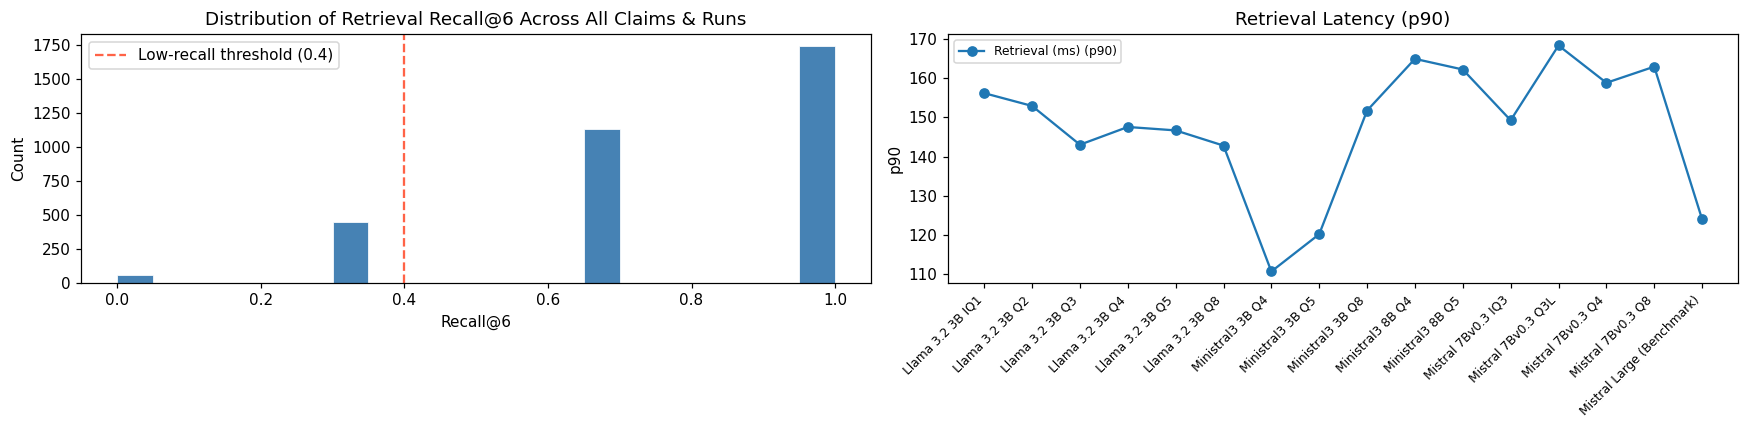

In [37]:
fig, (ax_hist, ax_ret) = plt.subplots(1, 2, figsize=(16, 4))

ax_hist.hist(
    df['metrics_recall_at_k'].dropna(),
    bins=20, color='steelblue', edgecolor='white', linewidth=0.5,
)
ax_hist.axvline(0.4, color='tomato', linestyle='--', linewidth=1.5, label='Low-recall threshold (0.4)')
ax_hist.set_xlabel('Recall@6')
ax_hist.set_ylabel('Count')
ax_hist.set_title('Distribution of Retrieval Recall@6 Across All Claims & Runs')
ax_hist.legend()

plot_stats_multi_line(
    df,
    _present(df, ['latency_retrieval_latency_ms']),
    group_by='run_id', group_order=run_order,
    stat='p90', labels=labels, metric_labels=METRIC_LABELS,
    title='Retrieval Latency (p90)',
    ax=ax_ret,
)

plt.tight_layout()
plt.show()


---
## Mistral Family Outperforms Llama 3.2

Across most quantization levels, Ministral and Mistral models deliver meaningfully better correctness than Llama 3.2 3B, with additional, smaller improvements in hallucination and faithfulness.

The trade-off: Mistral-family generation runs roughly 2 seconds slower on average, though TTFT is comparable at ~1 second. At Q4, Ministral achieves ~51 tokens/sec vs ~48 for Llama; at Q5, ~42 vs ~38. Llama, however, consumes 300–400 MB more RAM at equivalent quantization, suggesting less efficient memory access patterns.

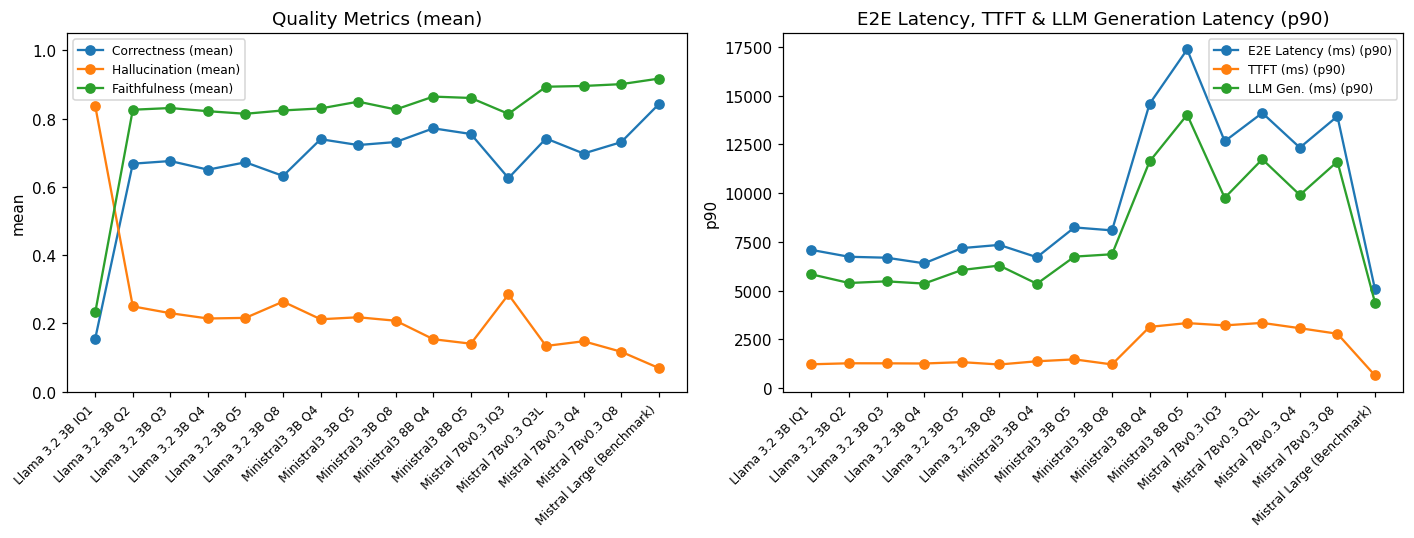

In [40]:
fig, (ax_q, ax_lat) = plt.subplots(1, 2, figsize=(13, 5))

plot_stats_multi_line(
    df, _present(df, quality_cols),
    group_by='run_id', group_order=run_order,
    labels=labels, metric_labels=METRIC_LABELS,
    ylim=(0, 1.05),
    title='Quality Metrics (mean)',
    ax=ax_q,
)
plot_stats_multi_line(
    df,
    _present(df, ['latency_e2e_latency_ms', 'latency_ttft_ms', 'latency_llm_generation_latency_ms']),
    group_by='run_id', group_order=run_order,
    stat='p90', labels=labels, metric_labels=METRIC_LABELS,
    title='E2E Latency, TTFT & LLM Generation Latency (p90)',
    ax=ax_lat,
)

plt.tight_layout()
plt.show()


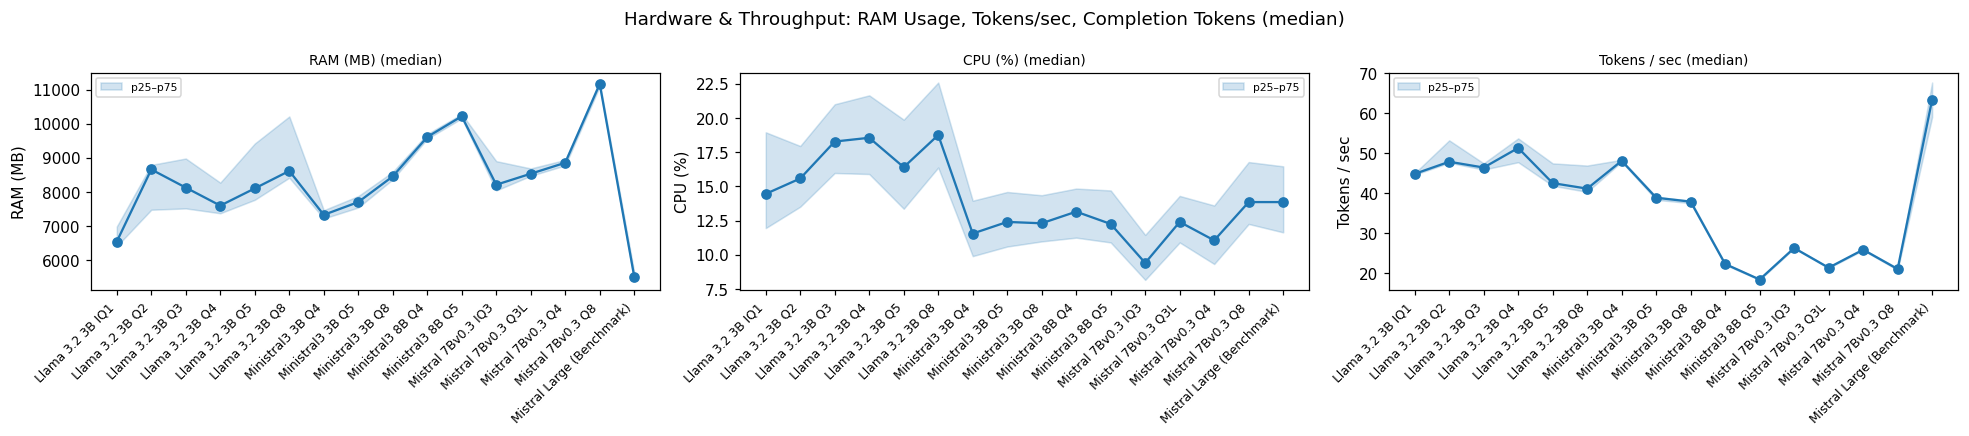

(<Figure size 1980x440 with 3 Axes>,
 [<Axes: title={'center': 'RAM (MB) (median)'}, ylabel='RAM (MB)'>,
  <Axes: title={'center': 'CPU (%) (median)'}, ylabel='CPU (%)'>,
  <Axes: title={'center': 'Tokens / sec (median)'}, ylabel='Tokens / sec'>])

In [ ]:
# 
plot_stats_line(
    df,
    _present(df, ['hardware_max_ram_usage_mb', 'hardware_avg_cpu_utilization_pct', 'generation_tokens_per_second']),
    group_by='run_id', group_order=run_order,
    stat='median', show_band=True, labels=labels, metric_labels=METRIC_LABELS,
    figsize_per_col=(6, 4),
    title='Hardware & Throughput: RAM Usage, Tokens/sec, Completion Tokens (median)',
)


---
## Quantization: Diminishing Returns, Collapse for very low quantization 

Within each model family, the returns diminish with increasing precision: moving from Q4 to Q5 to Q8 yields modest quality improvements at equally modest latency cost. The dramatic exception is extreme compression — **IQ1 and Q2 for Llama 3.2, and IQ3 for Mistral 7B produce near-gibberish outputs**, collapsing correctness toward zero and hallucination toward 1.0. The quality cliff is sharp, not gradual.

Expectedly, Apple silicon works better with Q4/Q8 quantizations: Mistral 7B at Q4 *outperforms* lower quantization levels on generation latency, explained by MPS hardware acceleration that is better aligned with 4-bit and 8-bit weight formats. Q8 performs nearly as fast as Q5 for both Llama and Ministral, meaning there is very little latency penalty for choosing the highest quality. But not only are the IQ quantizations slower for Mistral and Llama, they also drop substantially in quality (see Llama-IQ1 and Mistral-IQ3). Thus, using low quantizations on hardware unoptimized for it yields no advantage at all.

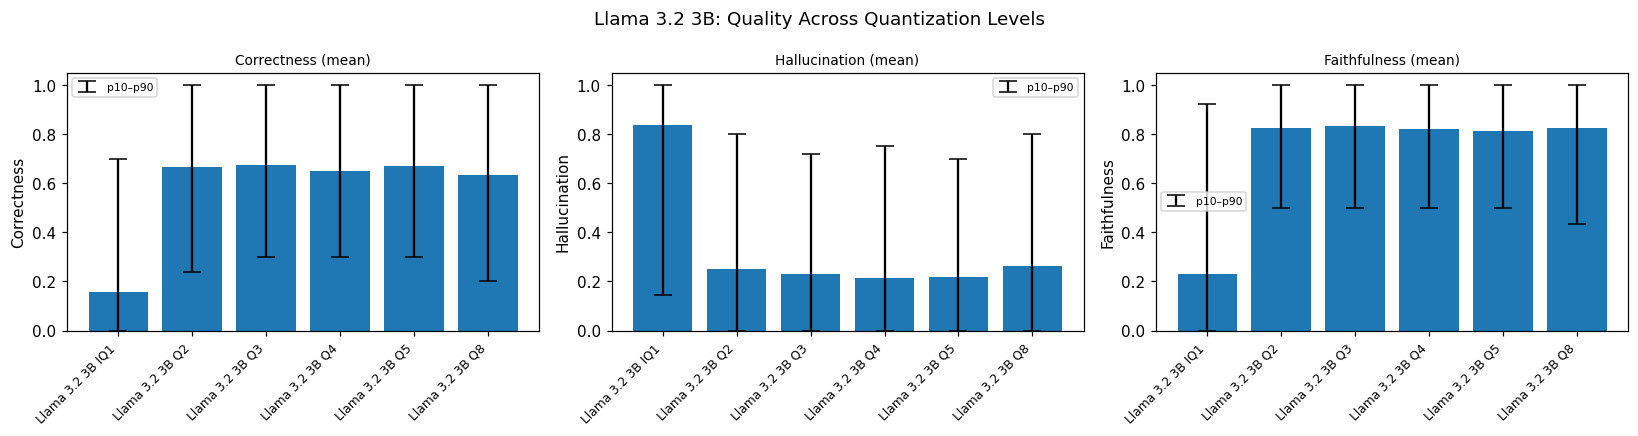

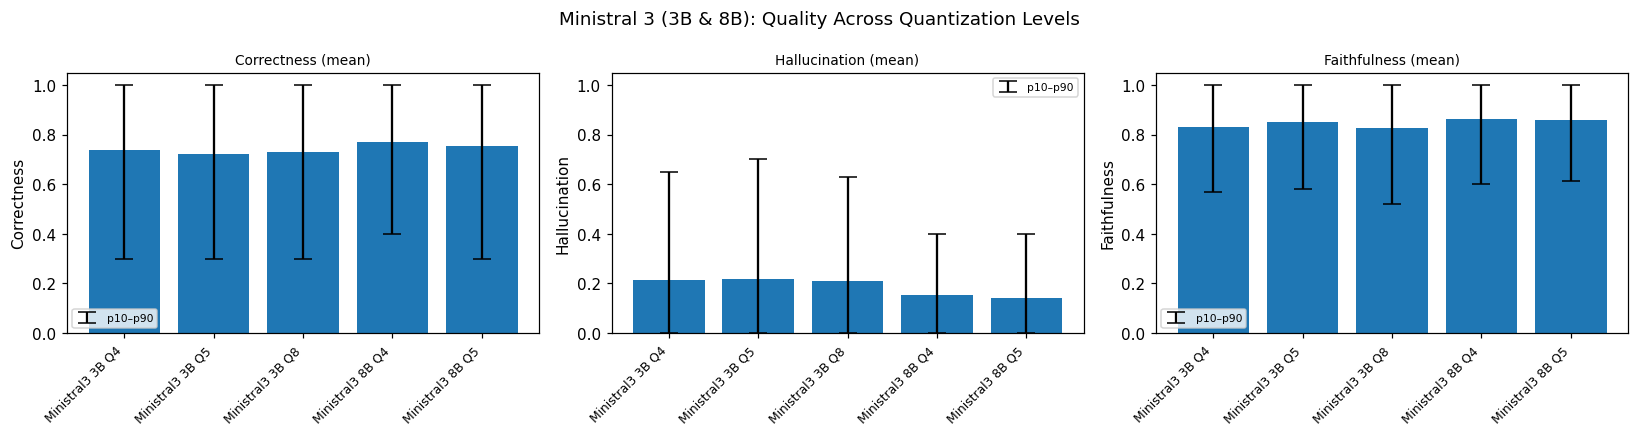

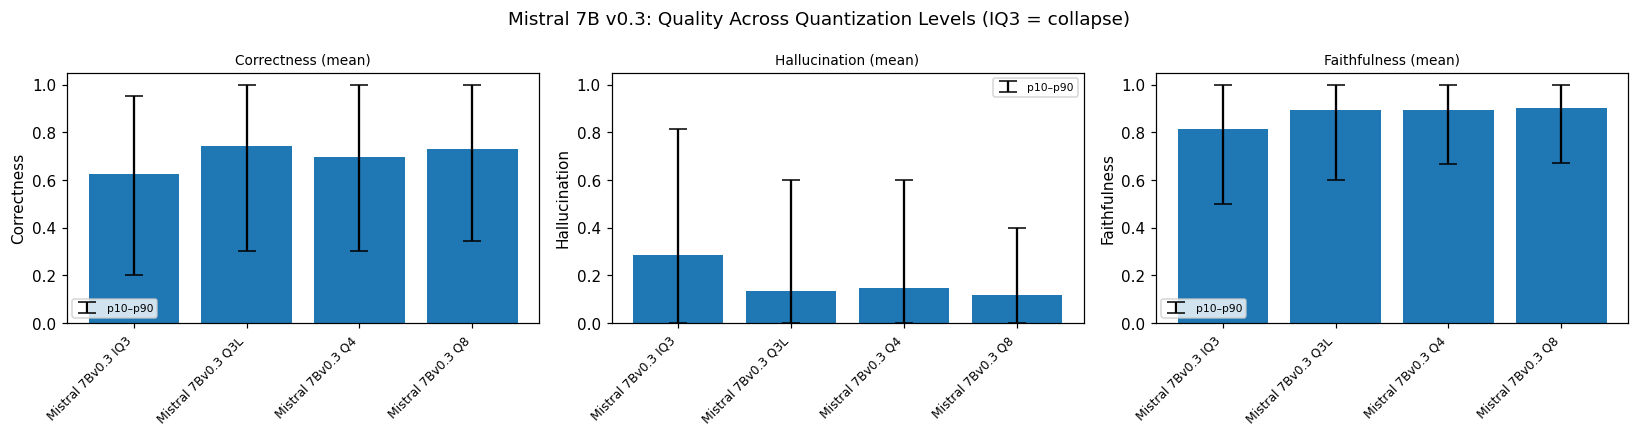

In [18]:
llama_order = [r for r in run_order if 'llama' in r]
ministral_order = [r for r in run_order if 'ministral' in r]
mistral_7b_order = [r for r in run_order if 'mistral_7B' in r]

for family_order, title in [
    (llama_order, 'Llama 3.2 3B: Quality Across Quantization Levels'),
    (ministral_order, 'Ministral 3 (3B & 8B): Quality Across Quantization Levels'),
    (mistral_7b_order, 'Mistral 7B v0.3: Quality Across Quantization Levels (IQ3 = collapse)'),
]:
    df_family = df[df['run_id'].isin(family_order)]
    plot_stats_bar(
        df_family, _present(df_family, quality_cols),
        group_by='run_id', group_order=family_order,
        stat='mean', show_band=True, band_percentiles=(10, 90),
        labels=labels, metric_labels=METRIC_LABELS,
        ylim=(0, 1.05),
        title=title,
    )
    plt.show()


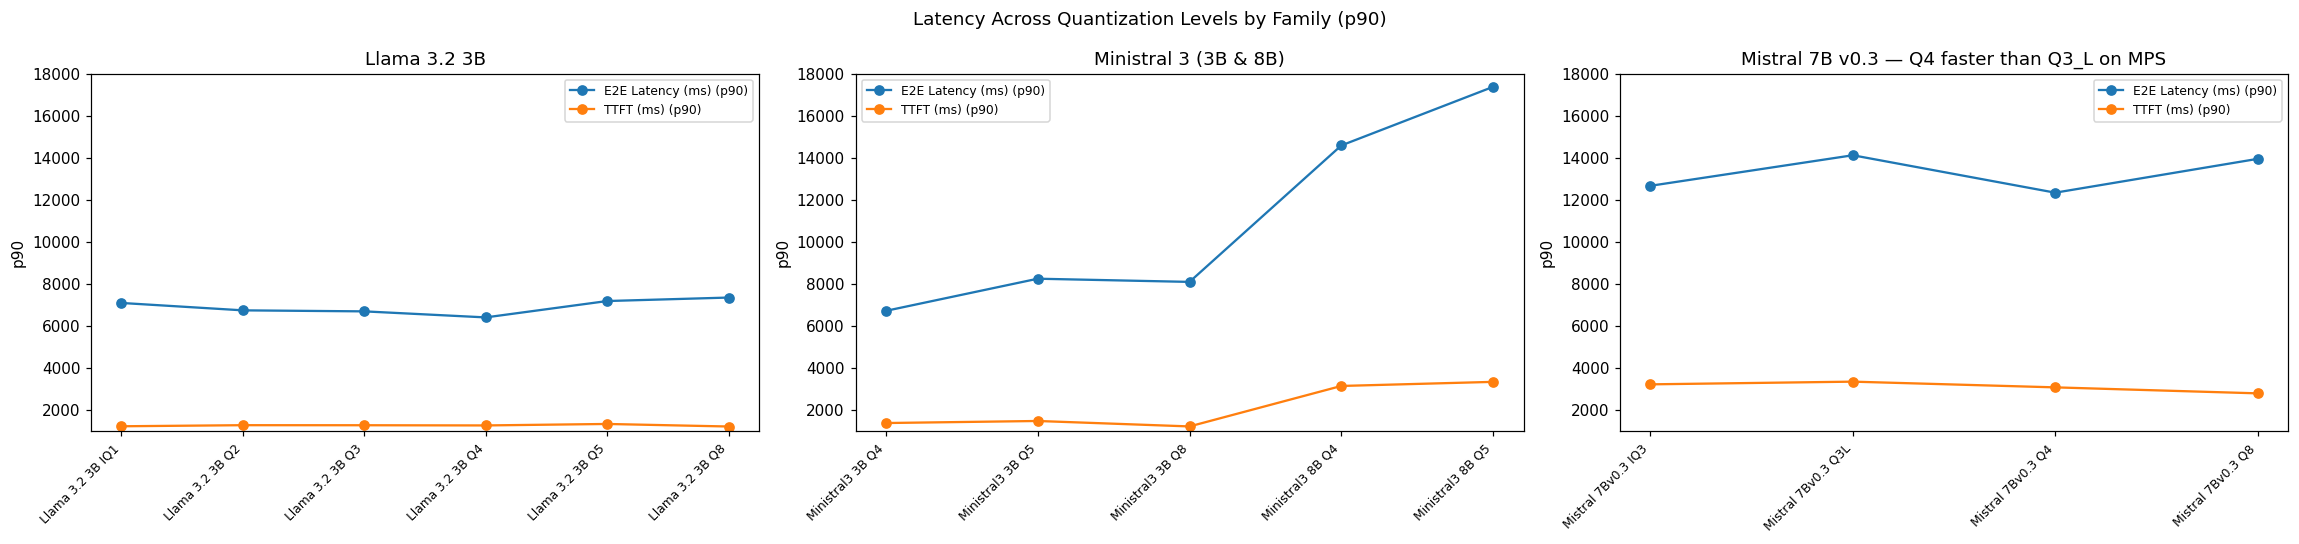

In [22]:
# Latency: MPS prefers Q4 and Q8 — visible especially in Mistral 7B
fig, (ax_llama, ax_ministral, ax_mistral7b) = plt.subplots(1, 3, figsize=(21, 5))

for ax, family_order, title in [
    (ax_llama,    llama_order,     'Llama 3.2 3B'),
    (ax_ministral, ministral_order, 'Ministral 3 (3B & 8B)'),
    (ax_mistral7b, mistral_7b_order, 'Mistral 7B v0.3 — Q4 faster than Q3_L on MPS'),
]:
    df_family = df[df['run_id'].isin(family_order)]
    plot_stats_multi_line(
        df_family,
        _present(df_family, ['latency_e2e_latency_ms', 'latency_ttft_ms']),
        group_by='run_id', group_order=family_order,
        stat='p90', labels=labels, metric_labels=METRIC_LABELS,
        title=title,
        ax=ax,
        ylim=(1000, 18000)
    )

fig.suptitle('Latency Across Quantization Levels by Family (p90)', fontsize=12)
plt.tight_layout()
plt.show()


---
## More Parameters Reduce Hallucination, But Latency Grows

Scaling parameter count brings a clear improvement in *faithfulness*, *hallucination*, and *correctness*. Mistral 7B and Ministral 8B perform similarly on both hallucination and faithfulness, which is an interesting finding due to the higher performance in benchmarks of Ministral. Hypothesizing, it could relate to the simplicity of the task (low context length, reduced need of reasoning due to the straight-forward structure "answer given this context"), where Ministral cannot play out its stronger reasoning performance. This would require further testing, e.g. with different inputs and potentially much longer context. A quick glance at the comparison of short vs. long context in this benchmarking does not give a conclusive answer, Ministral tends to perform better on shorter contexts, aligning with the other models. 

The latency cost is substantial: The E2E latency can be more than double (Ministral 3B vs 8B), which can be largely attributed to the increase in generation latency. The widening gap between generation latency and E2E latency can be attributed to a growing TTFT (from ~1.2 s at 3B to ~3s at 7B and beyond), reflecting the latency increase in prompt encoding. The parameter and architecture differences between Ministral and Mistral models become visible here, with Mistral generating an answer 2s faster on average. 

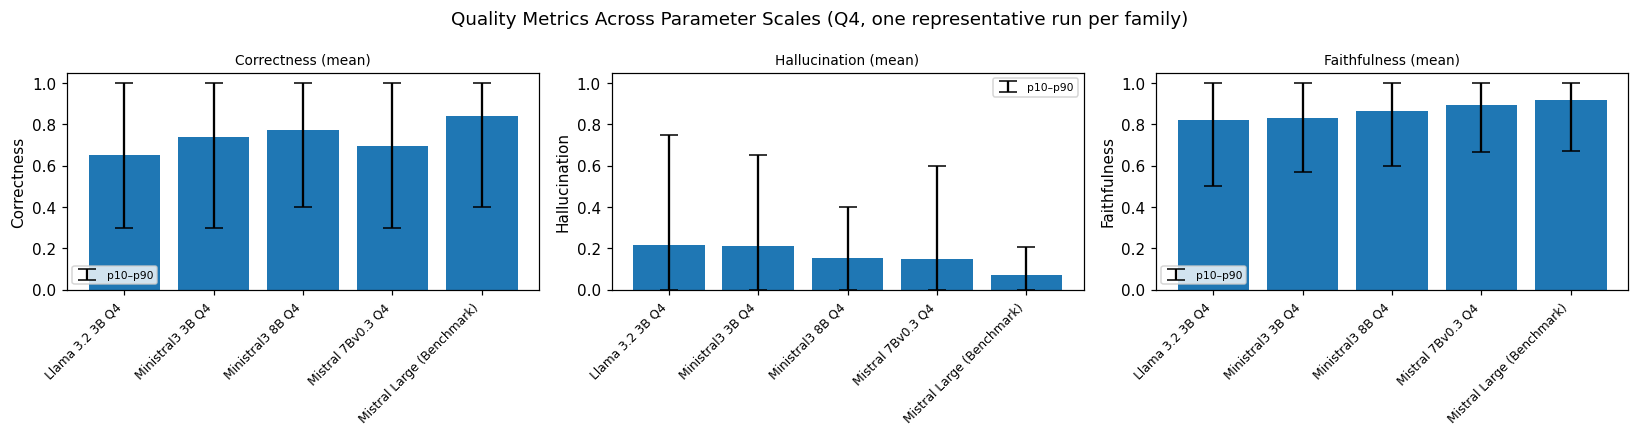

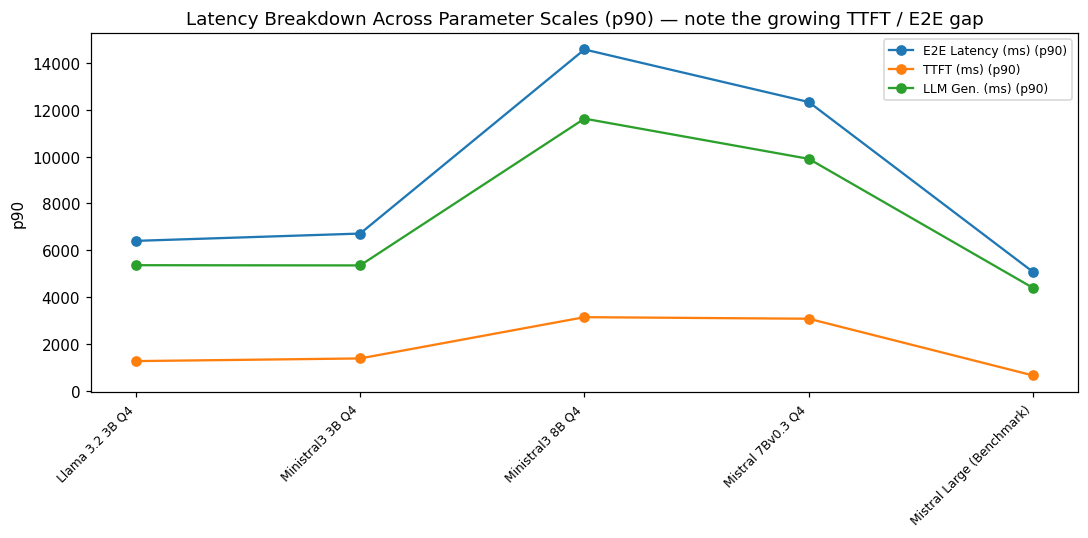

(<Figure size 1100x550 with 1 Axes>,
 <Axes: title={'center': 'Latency Breakdown Across Parameter Scales (p90) — note the growing TTFT / E2E gap'}, ylabel='p90'>)

In [41]:
# One representative Q4 run per parameter tier
param_order = [
    'e5_large_llama_3_2_3B_q4_61',
    'e5_large_test_ministral_3_3B_q4_61',
    'e5_large_test_ministral_3_8B_q4_61',
    'e5_large_test_mistral_7B_0_3_q4_61',
    'e5_large_mistral_large_latest_61',
]
df_params = df[df['run_id'].isin(param_order)]

plot_stats_bar(
    df_params, _present(df_params, quality_cols),
    group_by='run_id', group_order=param_order,
    stat='mean', show_band=True, band_percentiles=(10, 90),
    labels=labels, metric_labels=METRIC_LABELS,
    ylim=(0, 1.05),
    title='Quality Metrics Across Parameter Scales (Q4, one representative run per family)',
)

plot_stats_multi_line(
    df_params,
    _present(df_params, ['latency_e2e_latency_ms', 'latency_ttft_ms', 'latency_llm_generation_latency_ms']),
    group_by='run_id', group_order=param_order,
    stat='p90', labels=labels, metric_labels=METRIC_LABELS,
    title='Latency Breakdown Across Parameter Scales (p90) — note the growing TTFT / E2E gap',
)


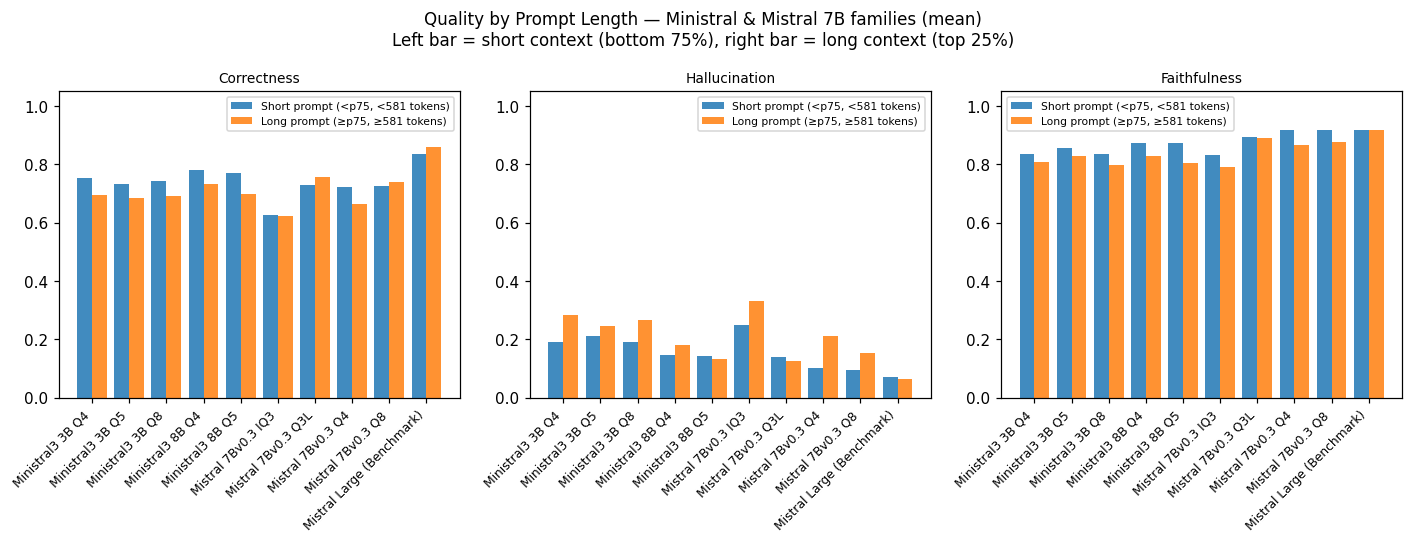

In [45]:
# Quality by prompt-token length: top 25% (long context) vs. bottom 75% (short context)
# Focus on Ministral and Mistral 7B families + Mistral Large benchmark
prompt_token_threshold = df['generation_prompt_tokens'].quantile(0.75)
df_long_prompt = df[df['generation_prompt_tokens'] >= prompt_token_threshold]
df_short_prompt = df[df['generation_prompt_tokens'] < prompt_token_threshold]

mistral_family_order = [r for r in run_order if 'ministral' in r or 'mistral' in r]

fig, axes = plt.subplots(1, 3, figsize=(13, 5))

for ax, col in zip(axes, quality_cols):
    for df_split, split_label in [
        (df_short_prompt, f'Short prompt (<p75, <{prompt_token_threshold:.0f} tokens)'),
        (df_long_prompt, f'Long prompt (≥p75, ≥{prompt_token_threshold:.0f} tokens)'),
    ]:
        df_split_fam = df_split[df_split['run_id'].isin(mistral_family_order)]
        agg = df_split_fam.groupby('run_id')[col].mean().reindex(mistral_family_order)
        x = range(len(mistral_family_order))
        ax.bar(
            [xi + (0.2 if 'Long' in split_label else -0.2) for xi in x],
            agg.values, width=0.4, alpha=0.85, label=split_label,
        )
    ax.set_xticks(range(len(mistral_family_order)))
    ax.set_xticklabels(
        [labels.get(r, r) for r in mistral_family_order],
        rotation=45, ha='right', fontsize=8,
    )
    ax.set_title(METRIC_LABELS.get(col, col), fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=7)

fig.suptitle(
    'Quality by Prompt Length — Ministral & Mistral 7B families (mean)\n'
    'Left bar = short context (bottom 75%), right bar = long context (top 25%)',
    fontsize=11,
)
plt.tight_layout()
plt.show()


---
## The Trade-Off: Mistral 7B Q3_L vs. Ministral 3B Q8

Two configurations with nearly identical RAM footprints (~7.5 GB) arrive at very different operating points:

- **Ministral 3B Q8** scores similar on *correctness* and achieves much higher token throughput, with a lower TTFT (~0.9 s vs ~1.1 s for Mistral Q3_L) while generating more tokens.
- **Mistral 7B Q3_L** scores better on *faithfulness* and *hallucination* on average, but at the cost of higher p90 generation latency.

The choice depends on the use case: if you need fast throughput, Ministral 3B Q8 is the stronger pick. If source fidelity and reduced hallucination are the priority, e.g. in citation-sensitive applications, Mistral 7B Q3_L delivers. 

In [46]:
comparison_runs = ['e5_large_test_mistral_7B_0_3_q3l_61', 'e5_large_test_ministral_3_3B_q8_61']
df_compare = df[df['run_id'].isin(comparison_runs)]

cmp_agg = df_compare.groupby('run_id').agg(
    Correctness=('score_Correctness', 'mean'),
    Hallucination=('score_Evaluate Hallucination V2', 'mean'),
    Faithfulness=('score_Faithfulness custom', 'mean'),
    Tokens_per_sec=('generation_tokens_per_second', 'median'),
    Completion_tokens=('generation_completion_tokens', 'median'),
    RAM_MB=('hardware_max_ram_usage_mb', 'median'),
).round(2)

p90_cmp = (
    df_compare.groupby('run_id')[['latency_e2e_latency_ms', 'latency_ttft_ms']]
    .quantile(0.9).round(0).astype(int)
)
p90_cmp.columns = ['E2E p90 (ms)', 'TTFT p90 (ms)']
cmp_agg = cmp_agg.join(p90_cmp)
cmp_agg.index = cmp_agg.index.map(lambda x: labels.get(x, x))
cmp_agg.columns = [
    'Correctness', 'Hallucination', 'Faithfulness',
    'Tokens/sec', 'Completion tokens', 'RAM (MB)',
    'E2E p90 (ms)', 'TTFT p90 (ms)',
]

display(
    cmp_agg.style
    .background_gradient(subset=['Correctness', 'Faithfulness'], cmap='RdYlGn', axis=0)
    .background_gradient(subset=['Hallucination'], cmap='RdYlGn_r', axis=0)
)

,Correctness,Hallucination,Faithfulness,Tokens/sec,Completion tokens,RAM (MB),E2E p90 (ms),TTFT p90 (ms)
run_id,,,,,,,,
Ministral3 3B Q8,0.730000,0.210000,0.830000,37.910000,256.000000,8452.950000,8091,1213
Mistral 7Bv0.3 Q3L,0.740000,0.130000,0.890000,21.380000,110.000000,8531.500000,14118,3344


---
## When Retrieval Fails: Model Robustness Across Recall Regimes

Comparing low-recall (recall@6 < 0.4) and high-recall (recall@6 ≥ 0.8) claims side by side reveals how much of each model's quality is *retrieval-dependent* versus *inherent*. When context is good, most models score reasonably well. When context is poor, the differences compound: faithfulness and hallucination degrade for all models, but larger and better-trained models hold up more gracefully.

Key observations:
- **Mistral 7B and Ministral 8B show their strength under low recall.** Their stronger instruction-following and reasoning allow for better answers measured across faithfulness and hallucination, where smaller models tend to confabulate. While Ministral 8B and Mistral 7B perform similarly, it is worthwhile comparing Mistral 7B with its smaller counterparts due to the similar memory footprint. We observe a similar behaviour as for the architecture comparison before: Mistral scores better and more reliably for hallucination and faithfulness (highly relevant in RAG setting), but not for correctness,leaving this as trade-off to be considered together with throughput metrics.
- **Quantization level has surprisingly little impact on hallucination under low recall** — except at extreme compression (IQ1/IQ3), where output quality collapses entirely. For robustness to poor retrieval, model architecture matters far more than fine-tuning within the Q4–Q8 range.
- **The difference in correctness shows how much headroom each model has** when given good context, which is a useful reminder that fixing retrieval is usually a better investment than scaling the model.

Low-recall  (<0.4):  506 obs across 16 run_ids
High-recall (≥0.8): 1745 obs across 16 run_ids


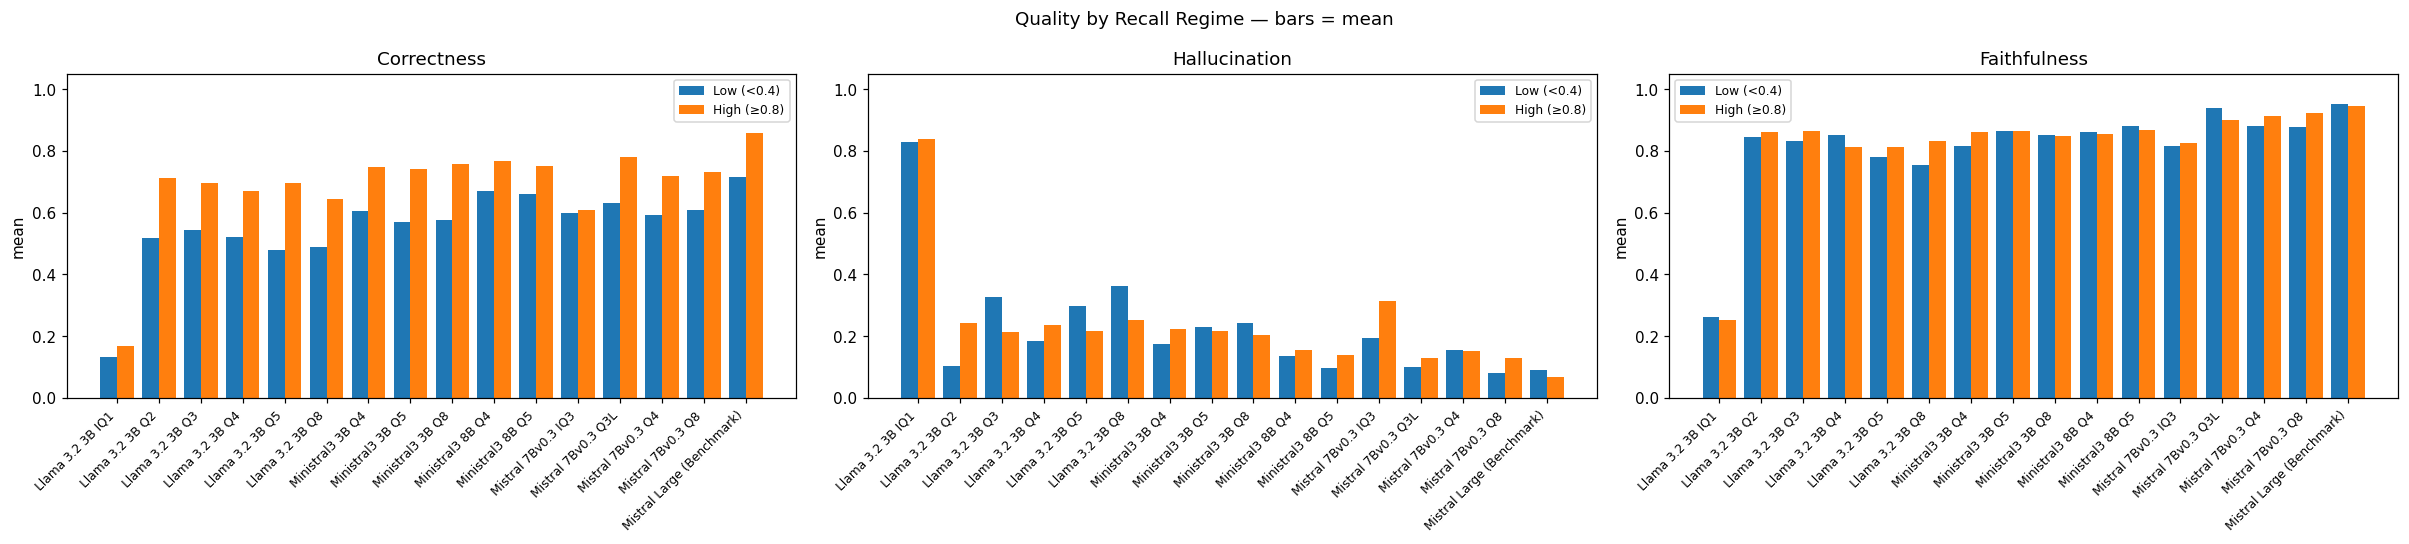

In [47]:
LOW_RECALL_THRESHOLD = 0.4
HIGH_RECALL_THRESHOLD = 0.8

df_low = df[df['metrics_recall_at_k'] < LOW_RECALL_THRESHOLD]
df_high = df[df['metrics_recall_at_k'] >= HIGH_RECALL_THRESHOLD]

print(f'Low-recall  (<{LOW_RECALL_THRESHOLD}):  {len(df_low)} obs across {df_low["run_id"].nunique()} run_ids')
print(f'High-recall (≥{HIGH_RECALL_THRESHOLD}): {len(df_high)} obs across {df_high["run_id"].nunique()} run_ids')

# --- Bar plots via plot_grouped_bars ---
df_combined = pd.concat([
    df_low.assign(recall_regime='Low (<0.4)'),
    df_high.assign(recall_regime='High (≥0.8)'),
])

metrics_bar = [
    ('score_Correctness', 'Correctness'),
    ('score_Evaluate Hallucination V2', 'Hallucination'),
    ('score_Faithfulness custom', 'Faithfulness'),
]

fig, axes = plt.subplots(1, 3, figsize=(22, 5))

for ax, (metric_col, title) in zip(axes, metrics_bar):
    df_w = (
        df_combined[['run_id', 'recall_regime', metric_col]]
        .assign(_obs=lambda d: d.groupby(['run_id', 'recall_regime']).cumcount())
        .pivot_table(
            values=metric_col,
            index=['recall_regime', '_obs'],
            columns='run_id',
            aggfunc='first',
        )
        .reset_index(level='_obs', drop=True)
        .reset_index()
    )
    valid_cols = [r for r in run_order if r in df_w.columns]
    plot_grouped_bars(
        df_w,
        cols=valid_cols,
        group_by='recall_regime',
        group_order=['Low (<0.4)', 'High (≥0.8)'],
        stat='mean',
        error=None,
        labels=labels,
        metric_labels=labels,
        title=title,
        ax=ax,
    )
    ax.set_ylim(0, 1.05)

fig.suptitle('Quality by Recall Regime — bars = mean', fontsize=12)
plt.tight_layout()
plt.show()

# --- Summary table: quality + completion tokens, Low/High as inner columns ---
def recall_agg(df_subset):
    return df_subset.groupby('run_id').agg(
        Correctness=('score_Correctness', 'mean'),
        Hallucination=('score_Evaluate Hallucination V2', 'mean'),
        Faithfulness=('score_Faithfulness custom', 'mean'),
        **{'Completion tokens': ('generation_completion_tokens', 'median')},
    ).round(2)

low_agg  = recall_agg(df_low)
high_agg = recall_agg(df_high)

combined = pd.concat({'Low (<0.4)': low_agg, 'High (≥0.8)': high_agg}, axis=1)
combined = combined.swaplevel(axis=1)
metric_order = ['Correctness', 'Hallucination', 'Faithfulness', 'Completion tokens']
recall_order = ['Low (<0.4)', 'High (≥0.8)']
combined = combined[[(m, r) for m in metric_order for r in recall_order]]
combined = combined.reindex([r for r in run_order if r in combined.index])
combined.index = combined.index.map(lambda x: labels.get(x, x))

def _highlight_q4_rows(df):
    """Draw a red border around every Q4 row."""
    styles = pd.DataFrame('', index=df.index, columns=df.columns)
    for row in df.index:
        if 'Q4' in str(row):
            styles.loc[row] = 'outline: 2px solid red; outline-offset: -1px'
    return styles

idx = pd.IndexSlice
(
    combined.style
    .background_gradient(
        subset=idx[:, idx[['Correctness', 'Faithfulness'], :]],
        cmap='RdYlGn', axis=None,
    )
    .background_gradient(
        subset=idx[:, idx[['Hallucination'], :]],
        cmap='RdYlGn_r', axis=None,
    )
    .background_gradient(
        subset=idx[:, idx[['Completion tokens'], :]],
        cmap='Blues', axis=None,
    )
    .format(lambda v: f'{v:.0f}' if v > 2 else f'{v:.2f}')
    .apply(_highlight_q4_rows, axis=None)
)


---
## Conclusion

The central question this benchmark set out to answer was: *for on-device RAG on Apple Silicon, which model configurations give you reliable, context-grounded answers at what system cost?*

**The Mistral family earns its memory footprint; Llama does less so.** Llama 3.2 3B consumes 300–400 MB *more* RAM than comparable Ministral configurations while delivering lower correctness, faithfulness, and hallucination scores — the extra memory overhead is not being converted into better answers. Ministral 3B Q4 or Q5 uses less system memory, generates faster, and produces better RAG outputs. The case for Llama 3.2 on this task is not supported by the data.

**Quantization interacts with hardware in a non-obvious way.** Apple Silicon's MPS backend is optimised for 4-bit and 8-bit weight formats: Q8 is nearly as fast as Q5 for both Llama and Ministral, making it the obvious choice when RAM is available; you pay effectively no extra latency for the highest quality within the safe compression range. Extreme quantization inverts this logic entirely: IQ1 and IQ3 still consume ~6–7 GB RAM and require several seconds of inference time while producing low-quality outputs.

**Parameter count is the most expensive knob to turn.** Ministral 8B's TTFT is 2x compared to Ministral 3B and its E2E latency climbs sharply — but the gains in faithfulness and hallucination are modest. Mistral 7B achieves better safety metrics than Ministral 8B without the same per-token latency increase, making it the more system-efficient path to RAG reliability. The increase in TTFT at 8B+ is itself a signal: prompt encoding is consuming an increasing share of the request budget, leaving less headroom for interactive use cases.

**Mistral 7B is the most stable generator across retrieval conditions.** Its output stability, combined with a memory footprint comparable to Ministral 3B Q8, makes Mistral 7B the better choice when retrieval quality cannot be guaranteed, for instance, in niche domains or sparse document collections. There is an additional efficiency argument: Mistral 7B produces significantly fewer completion tokens (82–124) than Ministral (200–256), meaning it does not pad its answers when context is limited, avoiding wasted compute on low-signal generations. The trade-off is higher latency and TTFT, making it better suited to scenarios where quality and stability matter more than throughput. However, its smaller Ministral 3B sibling is close in quality metrics, with way better latency and TTFT, showing how a model less than half the size can still uphold quality with largely better throughput metrics.

### Verdict
For on-device RAG where both answer quality and system load matter, Mistral 7B Q4 on MPS provides the best quality per RAM-byte and the best generation latency with the highest adherence to context. Ministral 3B Q8, being close in quality to its larger sibling, is the right pick when throughput and correctness are the priority and the 7B latencies are unacceptable. Both are above Llama 3.2 in RAG quality at comparable or lower system cost, especially when retrieval fails.

### Open questions
A clearer Q4 → Q5 → Q8 quality ordering within each family requires more experimental runs; cross-platform comparisons (NVIDIA CUDA, CPU-only) are not yet available but are directly supported by the OTEL-native benchmarking framework, do the increased reasoning capabilities of Ministral pay off in a different RAG setting (more context to be loaded, increased content complexity, increased RAG pipeline complexity).

---
## Appendix: Detailed Distributions

The plots below provide additional distributional detail across all 16 configurations. They are provided for completeness and deeper inspection rather than as part of the main narrative — useful for anyone who wants to explore the full shape of latency, hardware, or quality distributions per model.

In [ ]:
# Appendix: detailed bar plots with percentile error bars for all metric groups
for metric_cols, title in [
    (list(LATENCY_COLS.keys()), 'Latency Metrics — median, error bars: p25–p75'),
    (list(GENERATION_COLS.keys()), 'Generation Metrics — median, error bars: p25–p75'),
    (list(HARDWARE_COLS.keys()), 'Hardware Metrics — median, error bars: p25–p75'),
]:
    plot_stats_bar(
        df, _present(df, metric_cols),
        group_by='run_id', group_order=run_order,
        stat='median', show_band=True, band_percentiles=(25, 75),
        labels=labels, metric_labels=METRIC_LABELS,
        title=title,
    )
    plt.show()


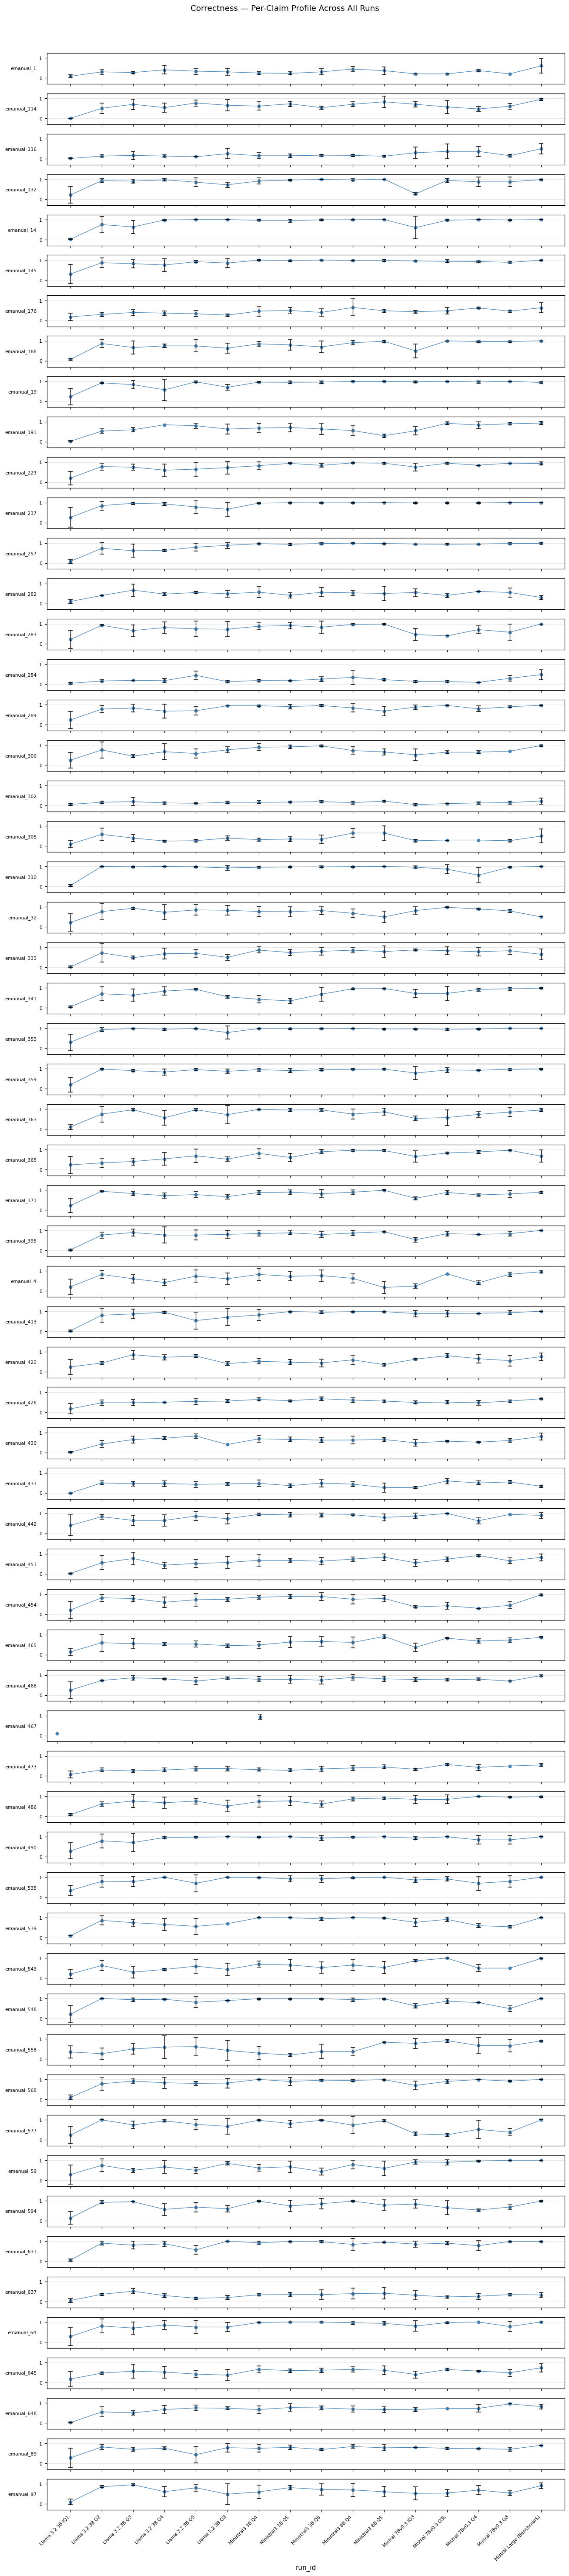

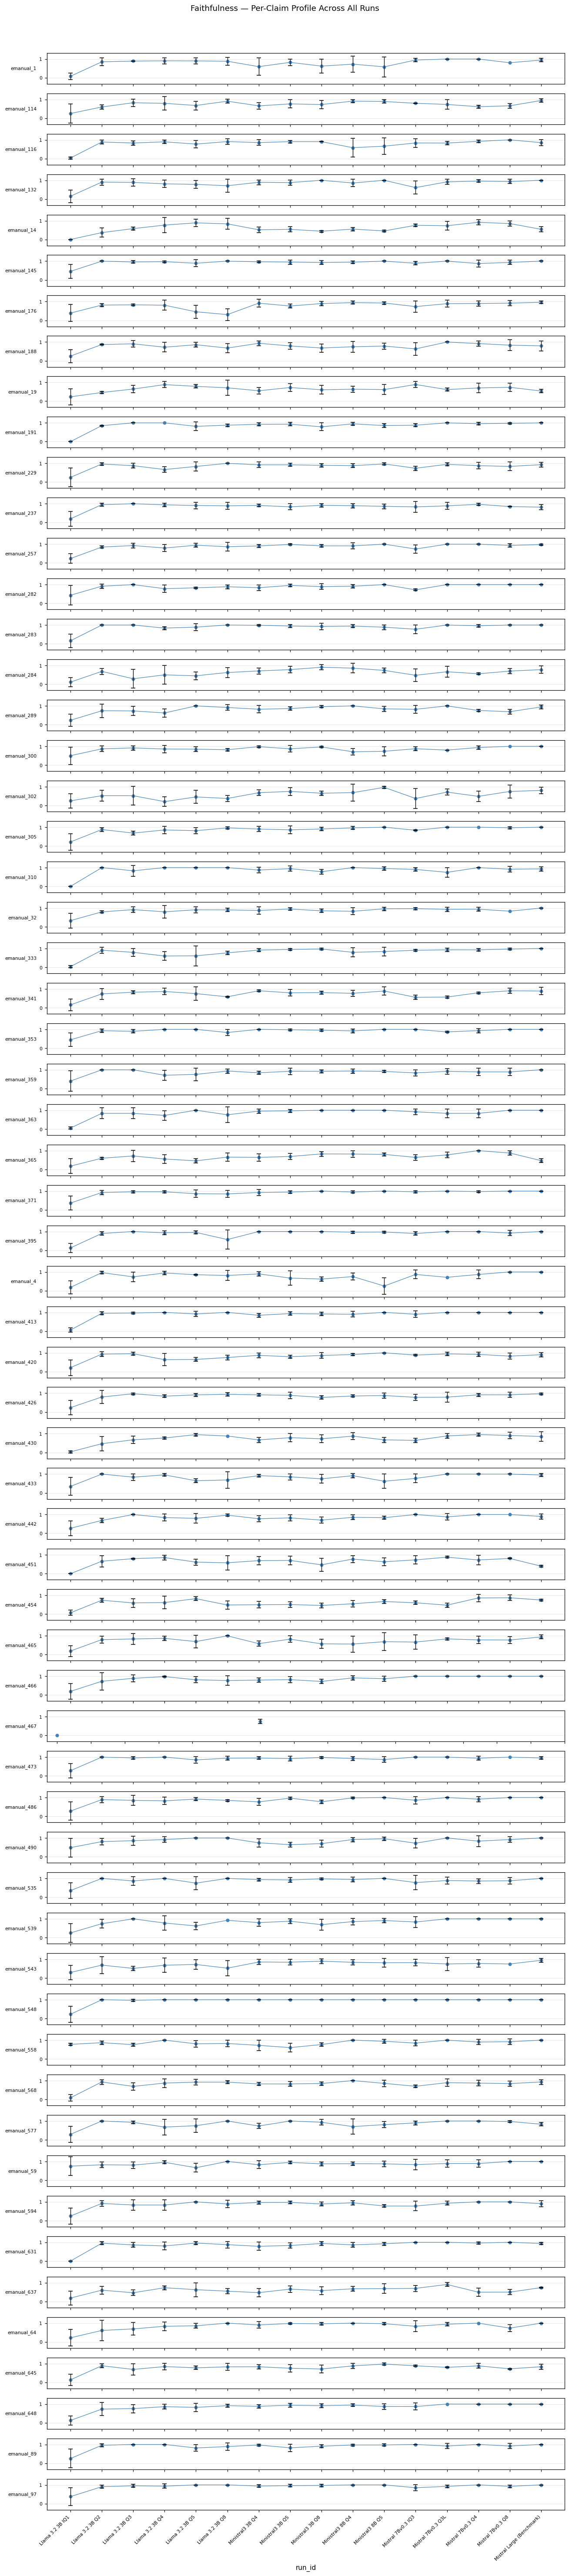

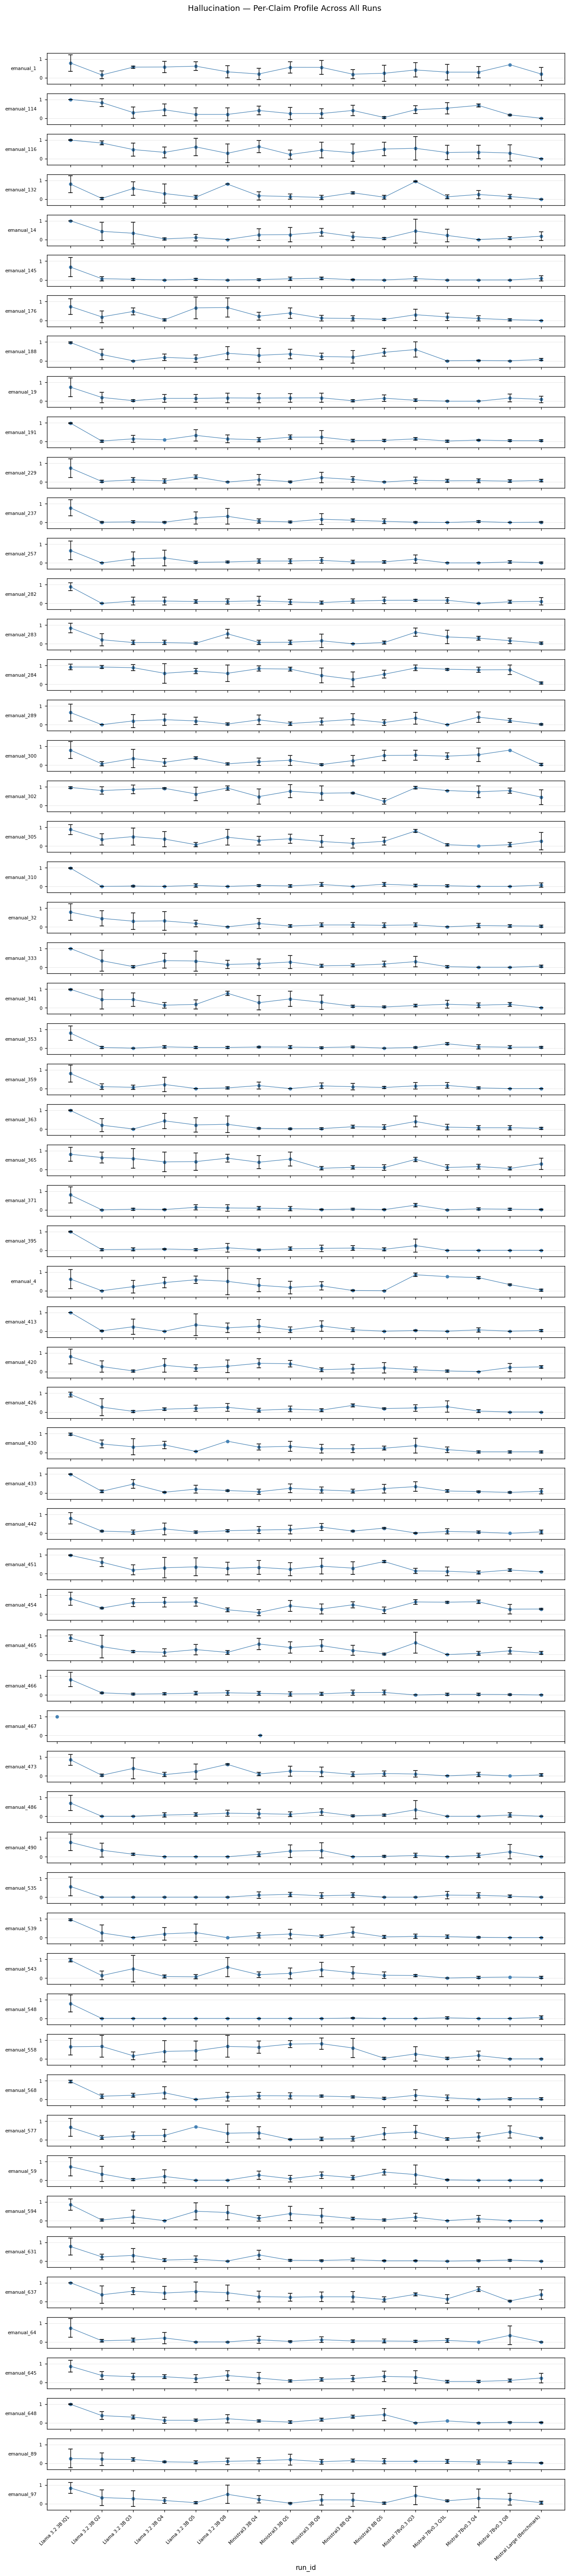

In [11]:
# Dot profiles: per-claim view of quality scores across all runs
for metric in ['score_Correctness', 'score_Faithfulness custom', 'score_Evaluate Hallucination V2']:
    plot_dot_profiles(
        df, metric=metric,
        var1_order=run_order,
        show_std=True, sharey=True,
        labels=labels,
        figsize_per_row=(12, 0.9),
        title=METRIC_LABELS.get(metric, metric) + ' — Per-Claim Profile Across All Runs',
    )
